Advanced Clustering - Python - 5/2/2026 - derave1577

In [2]:
import numpy as np
from sklearn.datasets import fetch_species_distributions
# Fetch the dataset
data = fetch_species_distributions()
# Extract geographical coordinates (longitude and latitude) from the data
longitude = data.train['dd long']
latitude = data.train['dd lat']
coordinates = np.vstack((longitude, latitude)).T
# Display the first few rows to understand what the data looks like
from IPython.display import display, Markdown
from datetime import datetime
todays_date = datetime.now().strftime("%Y-%m-%d")
student_id = "derave1577"
display(Markdown("### Step 1.2: Load the Dataset"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
print("First 5 values of the dataset:")
print(data.train[:5])

### Step 1.2: Load the Dataset

Date: 2026-05-02

Student ID: derave1577

First 5 values of the dataset:
[(b'microryzomys_minutus', -64.7   , -17.85  )
 (b'microryzomys_minutus', -67.8333, -16.3333)
 (b'microryzomys_minutus', -67.8833, -16.3   )
 (b'microryzomys_minutus', -67.8   , -16.2667)
 (b'microryzomys_minutus', -67.9833, -15.9   )]


In [3]:
display(Markdown("### Step 1.3: Initial Exploration of the Dataset"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Get a concise summary of the DataFrame
print(f"Data Summary: {data.train.dtype}")
# Get the shape of the dataset's features
print(f"Training data shape: {data.train.shape}")
print(f"Testing data shape: {data.test.shape}")
print(f"Coverages shape: {data.coverages.shape}")

### Step 1.3: Initial Exploration of the Dataset

Date: 2026-05-02

Student ID: derave1577

Data Summary: [('species', 'S22'), ('dd long', '<f4'), ('dd lat', '<f4')]
Training data shape: (1624,)
Testing data shape: (620,)
Coverages shape: (14, 1592, 1212)


### Step 2.1: Hierarchical Clustering

Date: 2026-05-02

Student ID: derave1577

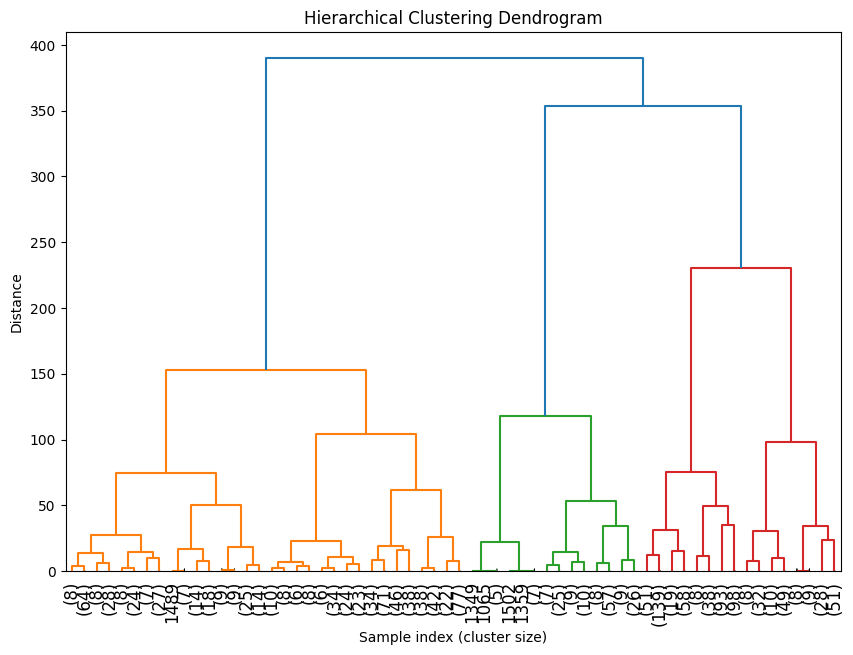

In [4]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
display(Markdown("### Step 2.1: Hierarchical Clustering"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Perform hierarchical clustering to find a starting k
Z = linkage(coordinates, method='ward')
# Plot the dendrogram
plt.figure(figsize=(10, 7))
dendrogram(Z, truncate_mode='level', p=5, leaf_rotation=90., leaf_font_size=12., show_contracted=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample index (cluster size)')
plt.ylabel('Distance')
plt.show()

### Step 2.2: K-Means Clustering

Date: 2026-05-02

Student ID: derave1577

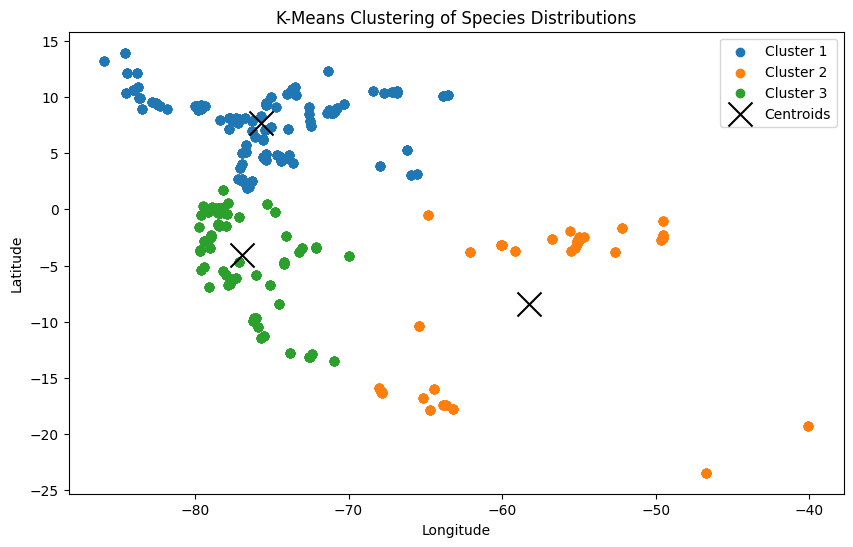

In [5]:
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt
display(Markdown("### Step 2.2: K-Means Clustering"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Ensure latitude and longitude are float
data.train['dd lat'] = data.train['dd lat'].astype(float)
data.train['dd long'] = data.train['dd long'].astype(float)
# Initialize the KMeans model
k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
# Fit the model to the data
kmeans.fit(coordinates)
# Get the cluster labels and centroids
labels = kmeans.labels_
centroids = kmeans.cluster_centers_
# Plot the clusters
plt.figure(figsize=(10, 6))
for i in range(k):
    cluster_points = coordinates[labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {i + 1}')
# Plot the centroids
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='black', marker='x', label='Centroids')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('K-Means Clustering of Species Distributions')
plt.legend()
plt.show()

### Step 2.3: Optimizing K-Means Clustering with Elbow Method

Date: 2026-05-02

Student ID: derave1577

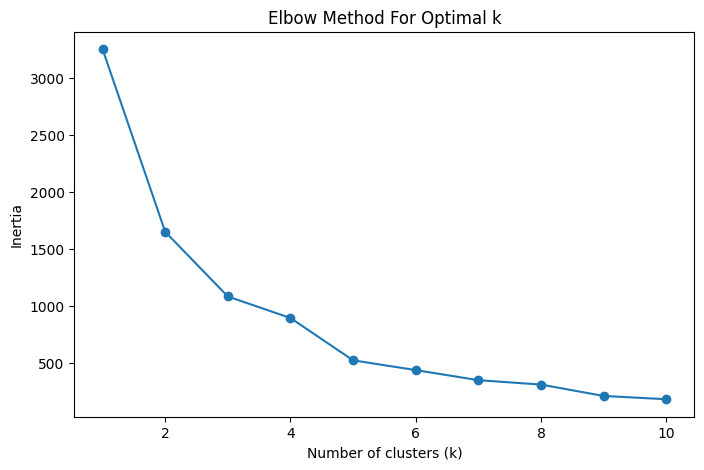

In [6]:
from sklearn.preprocessing import StandardScaler
display(Markdown("### Step 2.3: Optimizing K-Means Clustering with Elbow Method"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Standardize the data
scaler = StandardScaler()
coordinates = scaler.fit_transform(coordinates)
# Use Elbow Method to find optimal k
inertia = []
k_values = range(1, 11)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(coordinates)
    inertia.append(kmeans.inertia_)
# Plot the Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()

### Step 2.4: Silhouette Score for Optimal k

Date: 2026-05-02

Student ID: derave1577

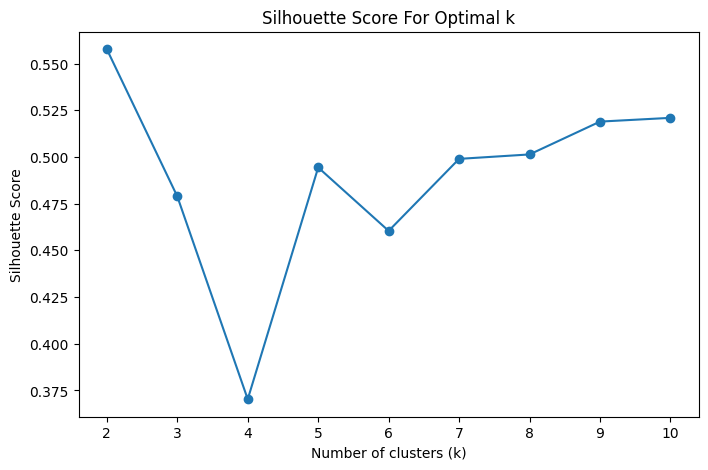

In [7]:
from sklearn.metrics import silhouette_score
display(Markdown("### Step 2.4: Silhouette Score for Optimal k"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Silhouette Score
silhouette_scores = []
# Calculate the Silhouette Score to find optimal k
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(coordinates)
    # Silhouette score is only defined for k > 1
    if k > 1:
        score = silhouette_score(coordinates, kmeans.labels_)
        silhouette_scores.append(score)
# Plot Silhouette Scores
plt.figure(figsize=(8, 5))
plt.plot(k_values[1:], silhouette_scores, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score For Optimal k')
plt.show()

### Step 2.5: K-Means Clustering on Geospatial Map

Date: 2026-05-02

Student ID: derave1577

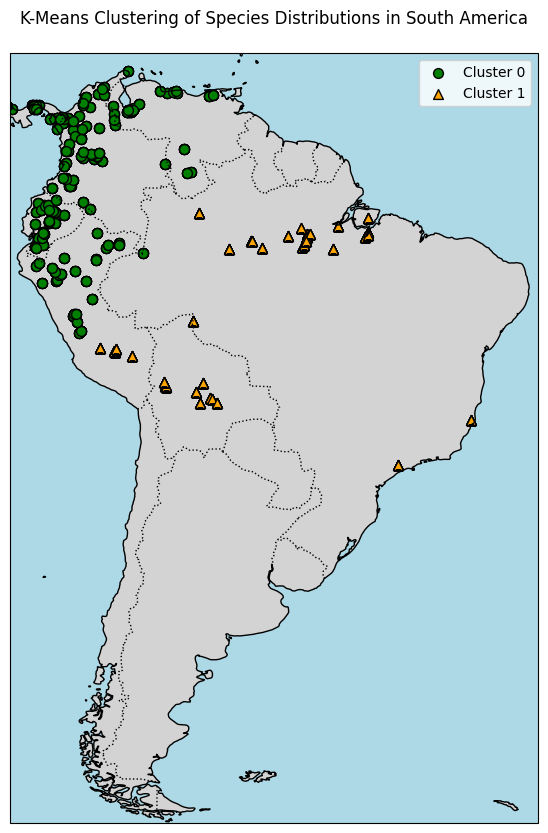

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')
display(Markdown("### Step 2.5: K-Means Clustering on Geospatial Map"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Apply K-Means algorithm with optimized number of clusters
points = np.vstack((longitude, latitude)).T
kmeans = KMeans(n_clusters=2, random_state=42).fit(points)
point_labels = kmeans.labels_
# Plot the results
plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
# Set the extent to South America
ax.set_extent([-82, -34, -56, 14], crs=ccrs.PlateCarree())
# Add features to the map
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
# Define colors and markers for training and test sets
colors = ['green', 'orange']
markers_train = ['o', '^']
# Plot data with different markers for each cluster
for i, (color, marker) in enumerate(zip(colors, markers_train)):
    idx = point_labels == i
    ax.scatter(points[idx, 0], points[idx, 1], c=color, marker=marker, label=f'Cluster {i}', transform=ccrs.PlateCarree(), edgecolors='k', s=50)
# Add labels and title
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('K-Means Clustering of Species Distributions in South America\n')
plt.legend()
plt.show()

### Step 3.1: Kernel Density Map

Date: 2026-05-02

Student ID: derave1577

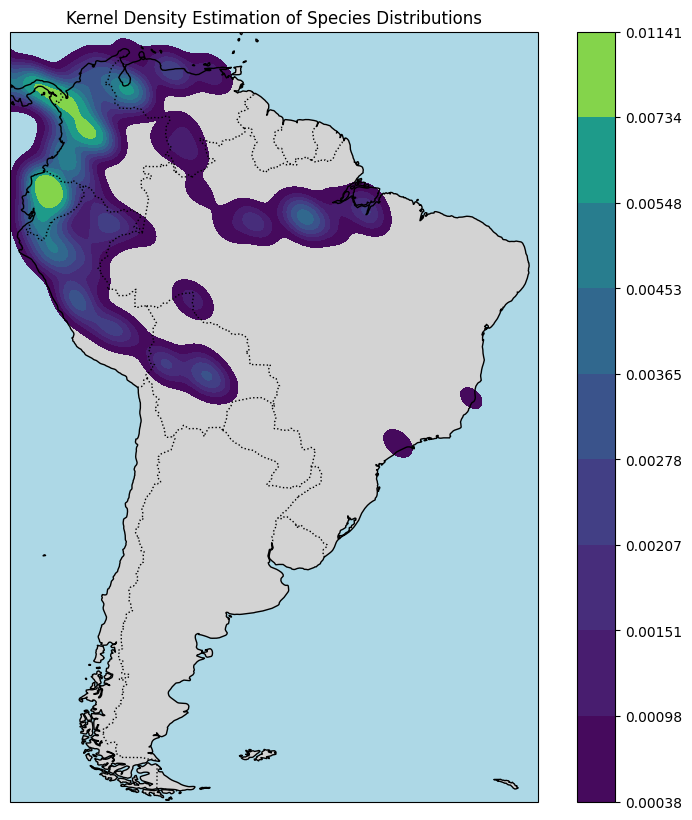

In [11]:
import seaborn as sns
display(Markdown("### Step 3.1: Kernel Density Map"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Set up the plot
plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
# Set the extent to South America
ax.set_extent([-82, -34, -56, 14], crs=ccrs.PlateCarree())
# Add features to the map
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
# Create a Kernel Density Estimate overlay
sns.kdeplot(x=longitude, y=latitude, cmap="viridis", fill=True, bw_adjust=0.5, cbar=True)
# Add labels and title, then display plot
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Kernel Density Estimation of Species Distributions')
plt.show()

### Step 3.2: Plotted Kernel Density Map

Date: 2026-05-02

Student ID: derave1577

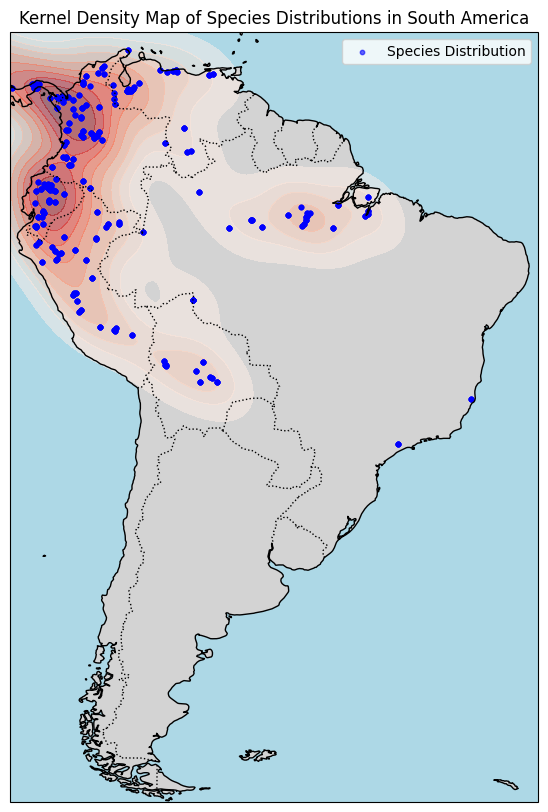

In [12]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
display(Markdown("### Step 3.2: Plotted Kernel Density Map"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Set up the plot
plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
# Set the extent to South America
ax.set_extent([-82, -34, -56, 14], crs=ccrs.PlateCarree())
# Add features to the map
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
# Overlay Kernel Density Estimate (KDE)
sns.kdeplot(x=longitude, y=latitude, cmap='Reds', fill=True, alpha=0.5, ax=ax)
# Scatter plot of the data points
plt.scatter(longitude, latitude, c='blue', s=10, label='Species Distribution', alpha=0.6, transform=ccrs.PlateCarree())
# Add labels and title
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Kernel Density Map of Species Distributions in South America')
plt.legend()
plt.show()